In [2]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv(r"C:\Users\pundr\Downloads\archive (1)\A_Z Handwritten Data.csv")
print(df.sample(5))
print(df.isnull().sum())

         0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.639  0.640  \
357755  24    0    0    0    0    0    0    0    0    0  ...      0      0   
73437    6    0    0    0    0    0    0    0    0    0  ...      0      0   
220906  16    0    0    0    0    0    0    0    0    0  ...      0      0   
336515  21    0    0    0    0    0    0    0    0    0  ...      0      0   
358452  24    0    0    0    0    0    0    0    0    0  ...      0      0   

        0.641  0.642  0.643  0.644  0.645  0.646  0.647  0.648  
357755      0      0      0      0      0      0      0      0  
73437       0      0      0      0      0      0      0      0  
220906      0      0      0      0      0      0      0      0  
336515      0      0      0      0      0      0      0      0  
358452      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
0        0
0.1      0
0.2      0
0.3      0
0.4      0
        ..
0.644    0
0.645    0
0.646    0
0.647    0
0.648  

In [11]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372450 entries, 0 to 372449
Columns: 785 entries, 0 to 0.648
dtypes: int64(785)
memory usage: 2.2 GB
None
(372450, 785)


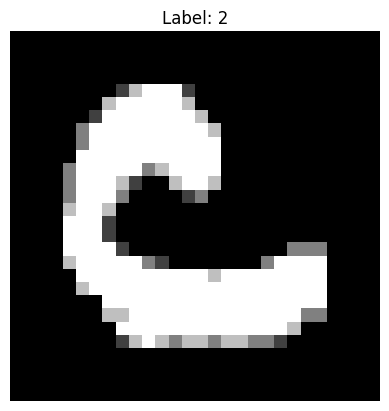

In [9]:
labels = df.iloc[:, 0]
pixels = df.iloc[:, 1:]
i = 40600	  # any index
img = pixels.iloc[i].values.reshape(28, 28)
plt.imshow(img, cmap='gray')
plt.title(f"Label: {labels.iloc[i]}")
plt.axis('off')
plt.show()



In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = df.iloc[:, 1:]
y = df.iloc[:, 0]
X= pd.DataFrame(X)
y = y.values.ravel()        

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.3,random_state=42)
lr = LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = lr.predict(X_test)
lr.score(X_test,y_test)

0.8785877298966304

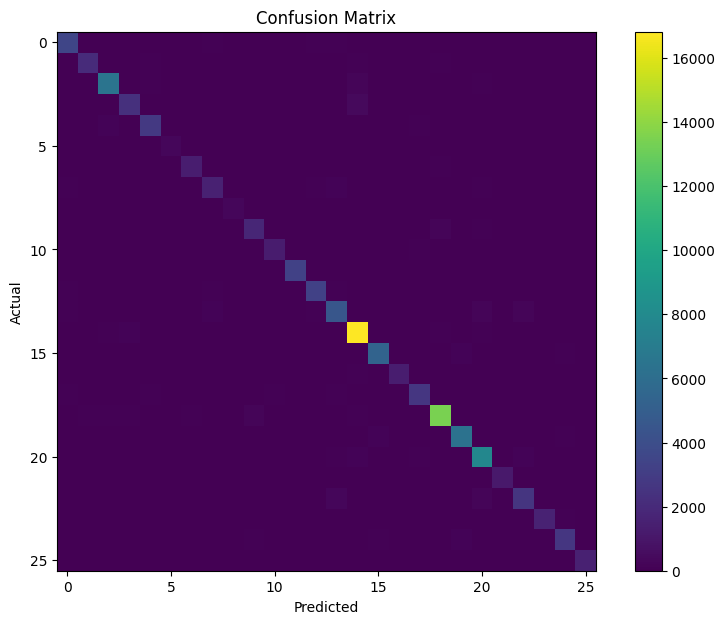

In [41]:


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


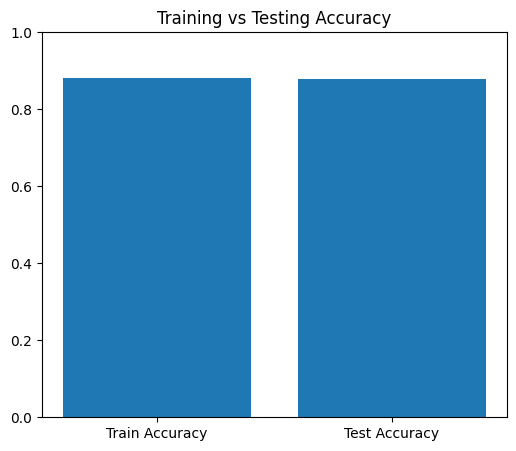

In [43]:
train_acc = lr.score(X_train, y_train)
test_acc = lr.score(X_test, y_test)

plt.figure(figsize=(6,5))
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc])
plt.ylim(0, 1)
plt.title("Training vs Testing Accuracy")
plt.show()


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


features = df.iloc[:, 1:]
targets = df.iloc[:, 0]


useful_cols = features.columns[(features != 0).any(axis=0)]
features = features[useful_cols]


feats_train, feats_test, targs_train, targs_test = train_test_split(
    features, targets, test_size=0.2, random_state=42, stratify=targets
)


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),      
    ("knn", KNeighborsClassifier(n_neighbors=5))   
])
pipeline.fit(feats_train, targs_train)


predictedknn = pipeline.predict(feats_test)


accuracyknn = accuracy_score(targs_test, predictedknn)
print("Accuracy:", accuracyknn)

# PCA final dimension
print("Reduced dimensions:", pipeline.named_steps["pca"].n_components_)


Accuracy: 0.9620083232648677
Reduced dimensions: 143


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score




useful_cols = features.columns[(features != 0).any(axis=0)]
features = features[useful_cols]


feat_train, feat_test, targ_train, targ_test = train_test_split(
    features, targets, test_size=0.2, random_state=42, stratify=targets
)


rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(feat_train, targ_train)


predicted = rf.predict(feat_test)


accuracy = accuracy_score(targ_test, predicted)
print("RF Accuracy:", accuracy)


RF Accuracy: 0.9885890723587059


In [25]:

sample_idx = np.random.choice(len(targ_test), 10, replace=False)


actual_sample = targ_test.iloc[sample_idx].values
pred_sample = predicted[sample_idx]

sample_df = pd.DataFrame({
    "Actual": actual_sample,
    "Predicted": pred_sample
}, index=sample_idx)

print(sample_df)


       Actual  Predicted
25908      25         25
50286      18         18
1677        3          3
36817       2          2
46532      14         14
58268      23         23
28702      20         20
7552       19         19
6824       22         22
62132      18         18


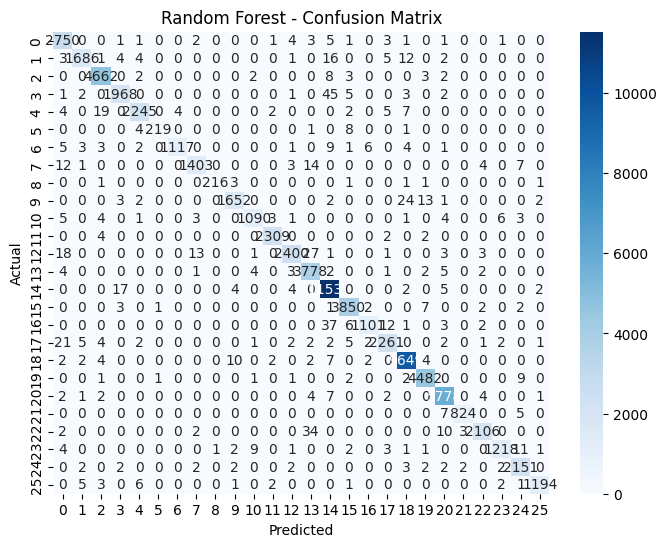

In [28]:

cm = confusion_matrix(targ_test, predicted)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


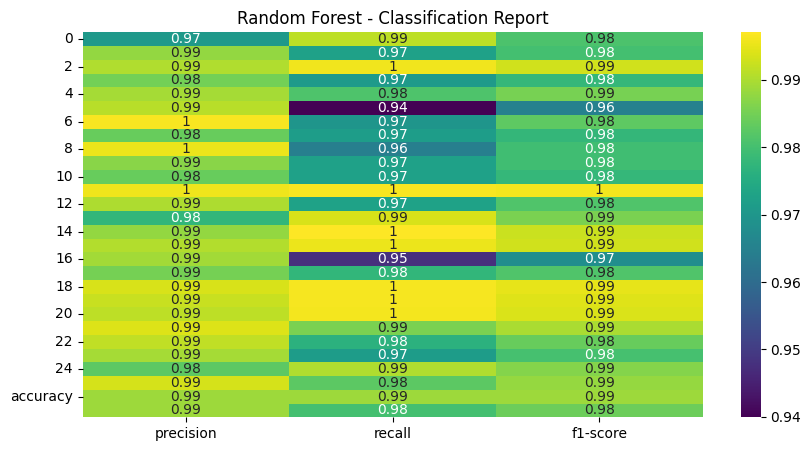

In [29]:
from sklearn.metrics import classification_report


report = classification_report(targ_test, predicted, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(10,5))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="viridis")
plt.title("Random Forest - Classification Report")
plt.show()


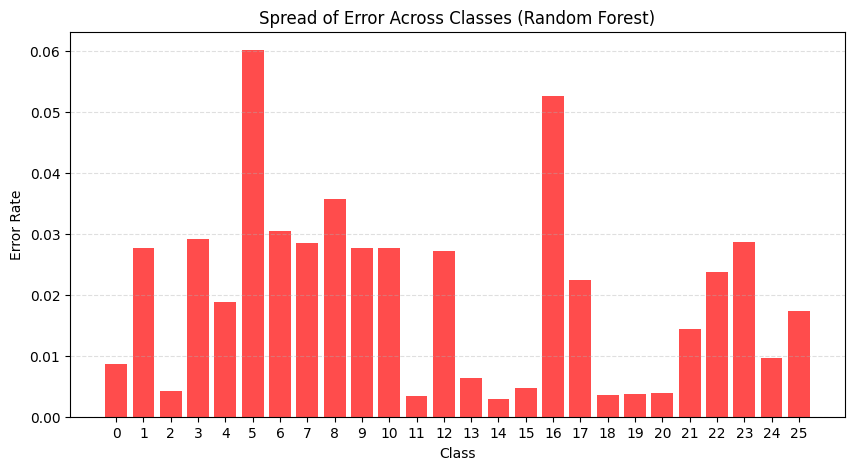

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Build dataframe of actual vs predicted
df_err = pd.DataFrame({
    "actual": targ_test.values,
    "pred": predicted
})

# Calculate error (1 = wrong, 0 = correct)
df_err["error"] = (df_err["actual"] != df_err["pred"]).astype(int)

# Calculate error rate for each class
error_by_class = df_err.groupby("actual")["error"].mean()

# ---- PLOT ----
plt.figure(figsize=(10,5))
plt.bar(error_by_class.index, error_by_class.values, color="red", alpha=0.7)
plt.xlabel("Class")
plt.ylabel("Error Rate")
plt.title("Spread of Error Across Classes (Random Forest)")
plt.xticks(error_by_class.index)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


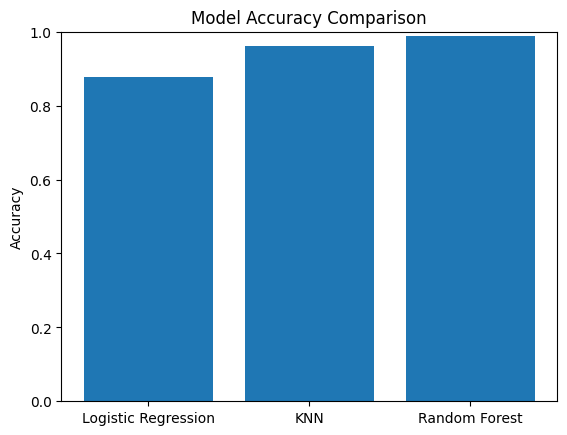

In [26]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "KNN", "Random Forest"]
accuracies = [lr.score(X_test,y_test), pipeline.score(feat_test,targ_test), accuracy_score(targ_test, predicted)]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.show()
